# Controling Params

In [ ]:
IMG_WIDTH = 128
IMG_HEIGHT = 128

## Data Loading (Labels)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
path = r"/content/drive/Dissertation"
os.chdir(path)

Mounted at /content/drive


In [ ]:
# Extracting Labels
import os
import pandas as pd

gender_map = {0: 'Male', 1: 'Female'}
race_map = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}

# Function to Extract Labels
def extract_labels(image_filename):
    try:
        basename = os.path.basename(image_filename)
        name, _ = os.path.splitext(basename)
        labels = name.split('_')
        return {
            'age': int(labels[0]),
            'gender': gender_map.get(int(labels[1]), 'Unknown'),
            'race': race_map.get(int(labels[2]), 'Unknown'),
            'datetime': labels[3]
        }
    except Exception as e:
        print(f"Error extracting labels from {image_filename}: {e}")
        return None

# Function to proccess image
def process_image_folder(folder_path):
    data = []
    for subdir, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".jpg"):
                file_path = os.path.join(subdir, file)
                labels = extract_labels(file_path)
                if labels:
                    labels['image_path'] = file_path
                    data.append(labels)
                else:
                    print(f"Skipping file due to label extraction error: {file_path}")
            else:
                print(f"Skipping non-image file: {file}")

    if data:
        df = pd.DataFrame(data)
    else:
        df = pd.DataFrame(columns=['age', 'gender', 'race', 'datetime', 'image_path'])
    return df
# Assigning Folder which contain images
main_folder = "data"
dataframe = process_image_folder(main_folder)

output_csv = 'demographic_features.csv'
dataframe.to_csv(output_csv, index=False)
print(f"Data has been processed and saved to {output_csv}")


Error extracting labels from data/part1/part1/61_1_20170109142408075.jpg: list index out of range
Skipping file due to label extraction error: data/part1/part1/61_1_20170109142408075.jpg
Error extracting labels from data/part1/part1/61_3_20170109150557335.jpg: list index out of range
Skipping file due to label extraction error: data/part1/part1/61_3_20170109150557335.jpg
Error extracting labels from data/part2/part2/53__0_20170116184028385.jpg: invalid literal for int() with base 10: ''
Skipping file due to label extraction error: data/part2/part2/53__0_20170116184028385.jpg
Error extracting labels from data/part2/part2/39_1_20170116174525125.jpg: list index out of range
Skipping file due to label extraction error: data/part2/part2/39_1_20170116174525125.jpg
Skipping non-image file: .DS_Store
Skipping non-image file: 44_1_4_20170116235150272.pg
Skipping non-image file: .DS_Store
Skipping non-image file: 55_0_0_20170116232725357jpg
Skipping non-image file: 44_1_4_20170116235150272.pg
Da

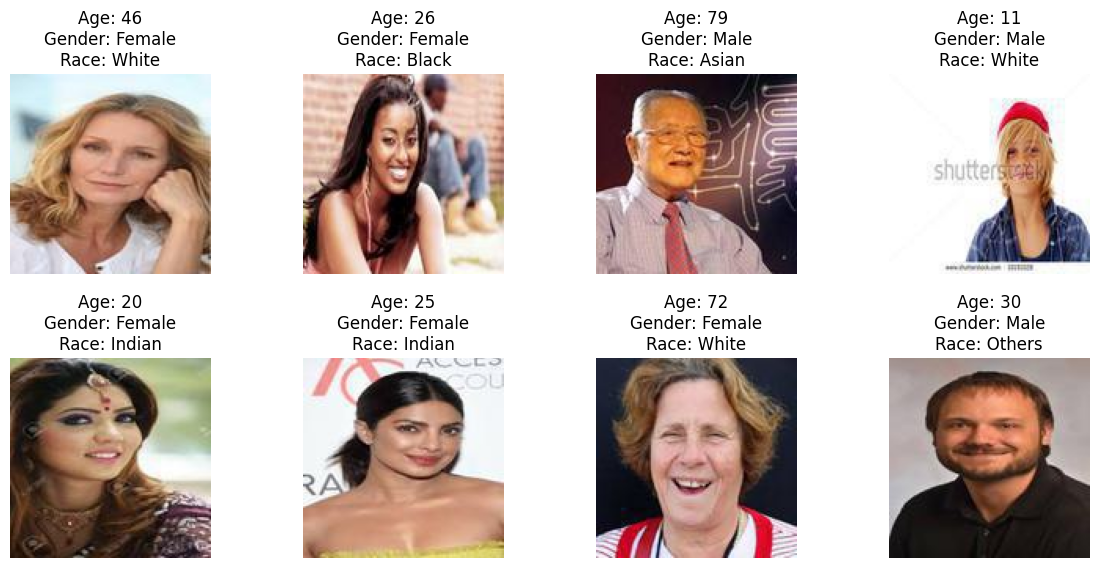

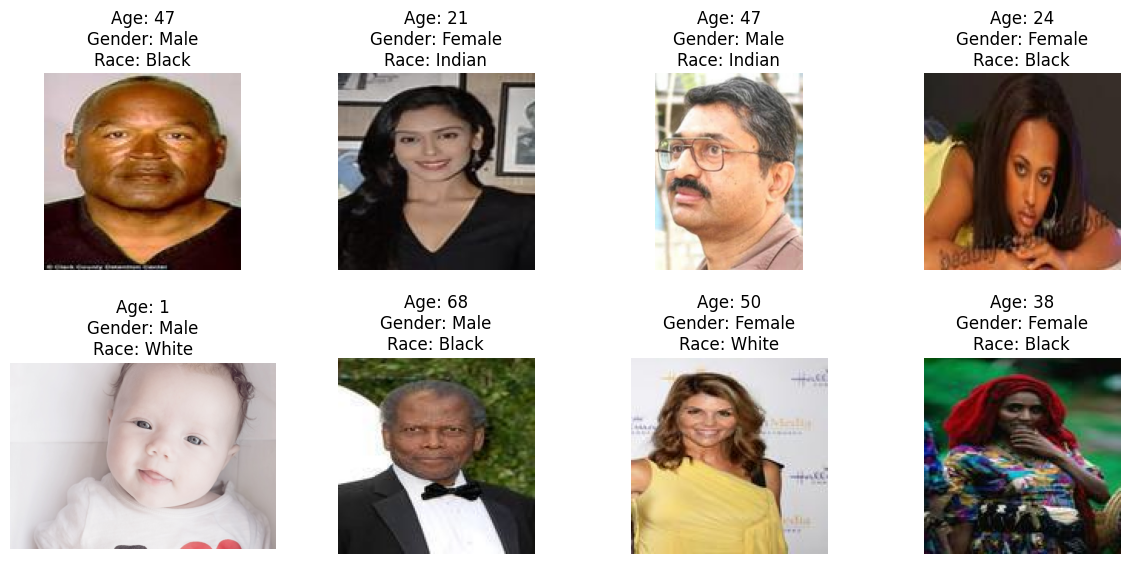

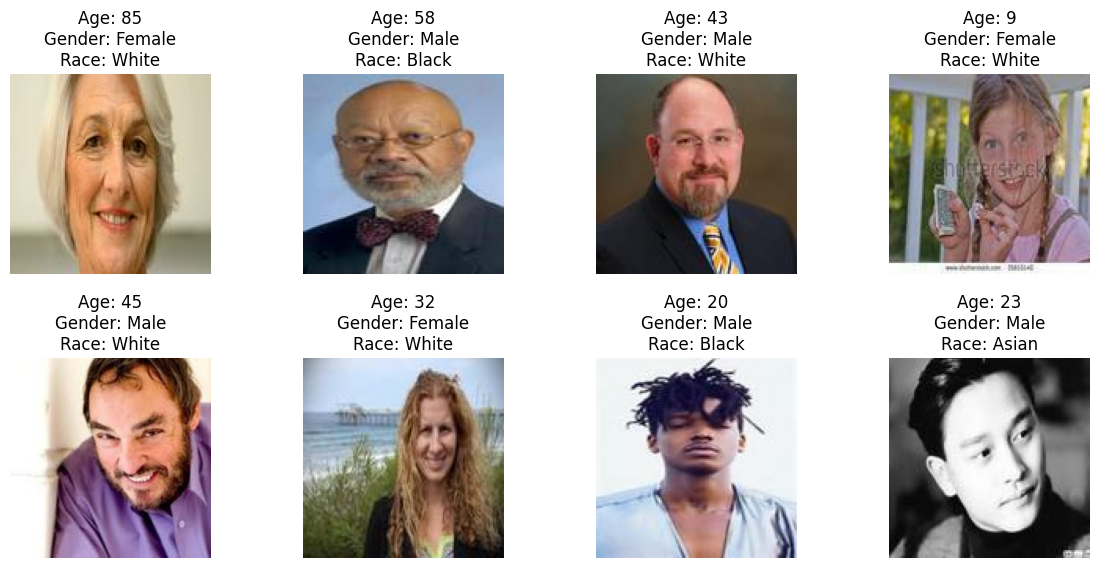

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image

# Reading csv file
df = pd.read_csv("demographic_features.csv")

# Function to display images
def display_images_grid(df):
    fig, axs = plt.subplots(2, 4, figsize=(12, 6))

    for i, row in df.sample(8).reset_index(drop=True).iterrows():
        img = Image.open(row['image_path'])

        ax = axs[i // 4, i % 4]
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Age: {row['age']}\nGender: {row['gender']}\nRace: {row['race']}")

    plt.tight_layout(pad=2)
    plt.show()
display_images_grid(df)
display_images_grid(df)
display_images_grid(df)

## Data Analysis

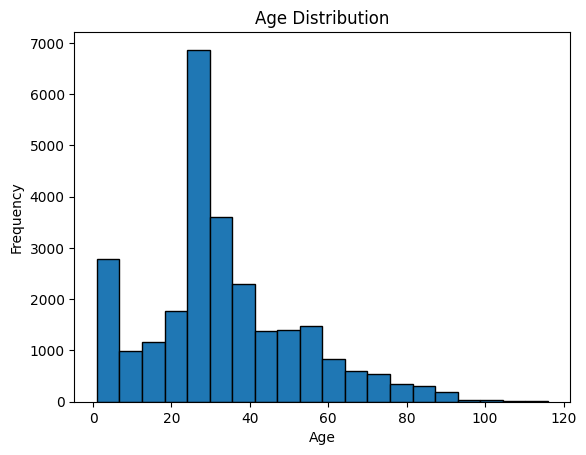

In [ ]:
# Ploting age distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.hist(df['age'], bins=20, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

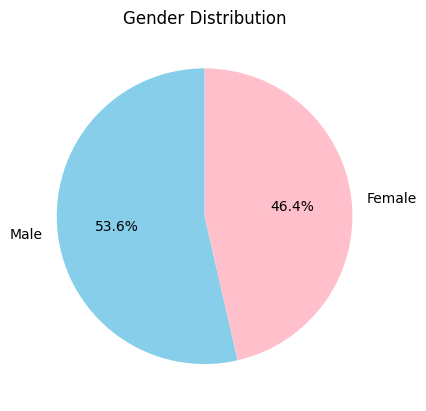

In [ ]:
# Ploting Gender Distribution
gender_counts = df['gender'].value_counts()
colors = ['skyblue', 'pink']
plt.pie(gender_counts, labels=gender_counts.index, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Gender Distribution')
plt.show()

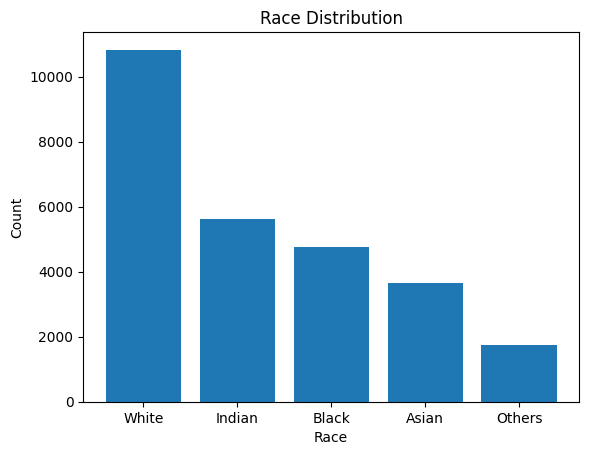

In [ ]:
# Ploting Race Destribution
race_counts = df['race'].value_counts()
plt.bar(race_counts.index, race_counts.values)

plt.title('Race Distribution')
plt.xlabel('Race')
plt.ylabel('Count')

plt.show()

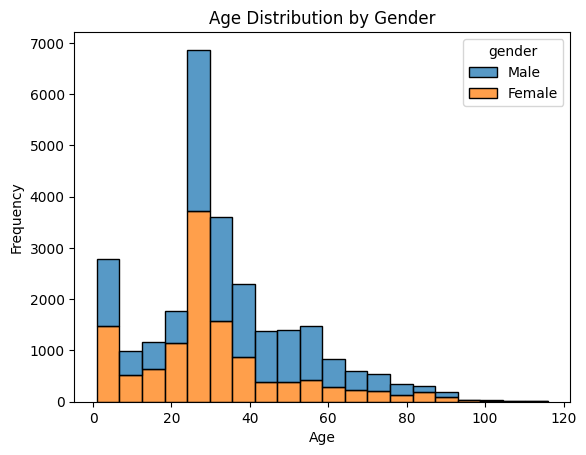

In [ ]:
# Ploting Age Distribution by Gender
sns.histplot(df, x='age', hue='gender', multiple='stack', bins=20)
plt.title('Age Distribution by Gender')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

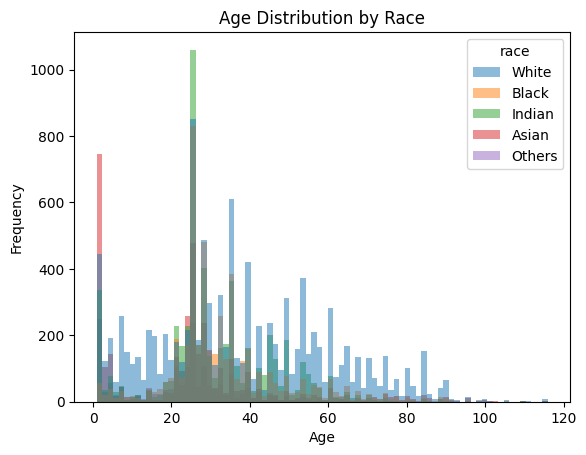

In [ ]:
# Age Distribution by Race
sns.histplot(df, x='age', hue='race', edgecolor=None)
plt.title('Age Distribution by Race')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

race    Asian  Black  Indian  Others  White
gender                                     
Female   1964   2302    2244     953   4900
Male     1694   2464    3391     794   5928


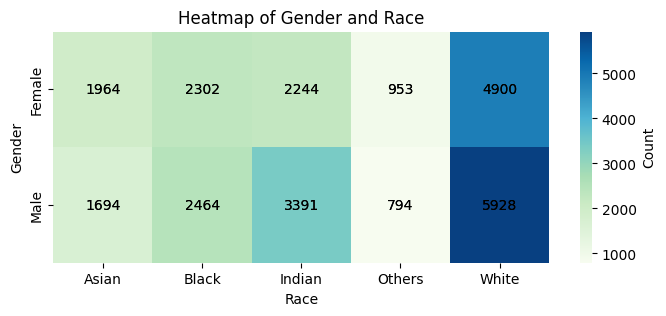

In [ ]:
# Plotting Heatmap of Gender and Race
gender_race_pivot = df.pivot_table(index='gender', columns='race', aggfunc='size', fill_value=0)
print(gender_race_pivot)
plt.figure(figsize=(8, 3))
ax = sns.heatmap(gender_race_pivot, annot=True, fmt='d', cmap='GnBu', cbar_kws={'label': 'Count'}, annot_kws={"size": 10, "color": "black"})
plt.title('Heatmap of Gender and Race')
plt.xlabel('Race')
plt.ylabel('Gender')
for y in range(gender_race_pivot.shape[0]):
    for x in range(gender_race_pivot.shape[1]):
        plt.text(x + 0.5, y + 0.5, gender_race_pivot.iloc[y, x], horizontalalignment='center', verticalalignment='center', color='black')
plt.show()

## Data Preproccessing

In [ ]:
# Removing images which were not extracted during data Loading in CSV file
values_to_remove = [
    r'data/part1/part1/16_0_0_20170110231918993.jpg',
    r'data/part1/part1/1_0_0_20170110212603790.jpg',
    r'data/part1/part1/1_0_0_20170110212658392.jpg',
    r'data/part1/part1/56_0_0_20170111202352043.jpg',
    r'data/part1/part1/70_0_0_20170111200757701.jpg',
    r'data/part1/part1/78_0_0_20170111221840478.jpg',
    r'data/part1/part1/80_1_0_20170110131953974.jpg',
    r'data/part1/part1/83_0_0_20170111221828238.jpg',
    r'data/part1/part1/85_0_0_20170111223921971.jpg'
]
df = df[~df['image_path'].isin(values_to_remove)]

In [ ]:
# Dropping Datetime column
df.drop('datetime',axis = 1, inplace = True)

<ipython-input-28-cf65fa836b35>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop('datetime',axis = 1, inplace = True)


In [ ]:
import numpy as np

# Counting Null values
df.replace([np.inf, -np.inf], np.nan).isna().sum().sum()


0

In [ ]:
# Sample of Data
df = df.sample(5000)

In [ ]:
# Storing Cleaned data
df.to_csv("prepared_data/demographic_features_cleaned.csv", index=False)

## Images Loading and Preparation for each Model

In [ ]:
import pandas as pd
df = pd.read_csv("prepared_data/demographic_features_cleaned.csv")

In [ ]:
import tensorflow as tf
from tqdm import tqdm

# Function to load and preprocess the image
def load_image(image_path, width=128, height=128):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [width, height])
    image = image / 255.0     # Normalize
    return image

In [ ]:
# Loading all Images
X_all_images = []
y_age = df.age.values

for image_path in tqdm(df.image_path):
  image = load_image(image_path)
  X_all_images.append(image)

X_all_images = np.array(X_all_images)

100%|██████████| 5000/5000 [32:32<00:00,  2.56it/s]


In [ ]:
np.save("prepared_data/X_images.npy", X_all_images)